# Kalshi 05 — active contract universe

Pull the complete active Kalshi market list from the unauthenticated public Trade API, join event metadata, and retain contracts in four research buckets:

- **Macro:** Economics, Financials, Commodities
- **Policy:** Politics, Elections
- **Single-industry:** Companies, Science and Technology, Crypto, Health, Transportation
- **Geopolitical:** World

Sports and entertainment are explicitly excluded. Climate/weather, mentions, social, uncategorized, and any other non-allowlisted categories remain available in the raw snapshot but are excluded from the research universe. The category allowlist is deliberately auditable and can be changed in one cell.

Kalshi's global market feed is dominated by multivariate sports parlays that do not carry joinable event-category metadata. The pull uses `mve_filter=exclude`, so “full active list” here means the complete active **standalone-contract** universe; this prevents excluded sports combinations from overwhelming the snapshot and makes the category filter auditable.

In [9]:
from datetime import datetime, timezone
from pathlib import Path
import json
import time

import pandas as pd
import requests

BASE_URL = "https://external-api.kalshi.com/trade-api/v2"
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
FULL_OUTPUT = OUTPUT_DIR / "kalshi_active_contracts_full.csv.gz"
FILTERED_OUTPUT = OUTPUT_DIR / "kalshi_active_contracts_filtered.csv"
SNAPSHOT_METADATA_OUTPUT = OUTPUT_DIR / "kalshi_active_contracts_snapshot_metadata.json"

BUCKET_BY_CATEGORY = {
    "Economics": "macro",
    "Financials": "macro",
    "Commodities": "macro",
    "Politics": "policy",
    "Elections": "policy",
    "Companies": "single-industry",
    "Science and Technology": "single-industry",
    "Crypto": "single-industry",
    "Health": "single-industry",
    "Transportation": "single-industry",
    "World": "geopolitical",
}
EXPLICITLY_EXCLUDED_CATEGORIES = {"Sports", "Entertainment"}

In [10]:
session = requests.Session()
session.headers.update({"User-Agent": "prediction-market-research/1.0"})


def fetch_all(endpoint, data_key, params, max_attempts=4):
    """Fetch every cursor-paginated row from a public Kalshi endpoint."""
    rows = []
    cursor = None
    page = 0

    while True:
        page_params = dict(params)
        if cursor:
            page_params["cursor"] = cursor

        for attempt in range(max_attempts):
            try:
                response = session.get(
                    f"{BASE_URL}/{endpoint}",
                    params=page_params,
                    timeout=60,
                )
                response.raise_for_status()
                payload = response.json()
                break
            except requests.RequestException:
                if attempt == max_attempts - 1:
                    raise
                time.sleep(2**attempt)

        batch = payload.get(data_key, [])
        rows.extend(batch)
        page += 1
        print(f"{endpoint} page {page}: {len(batch):,} rows; cumulative {len(rows):,}")

        cursor = payload.get("cursor")
        if not cursor:
            break
        time.sleep(0.05)

    return rows

In [11]:
snapshot_utc = datetime.now(timezone.utc).isoformat()

active_events_raw = fetch_all(
    endpoint="events",
    data_key="events",
    params={
        "status": "open",
        "limit": 200,
        "with_nested_markets": "false",
    },
)
active_markets_raw = fetch_all(
    endpoint="markets",
    data_key="markets",
    params={
        "status": "open",
        "limit": 1_000,
        # Kalshi's global feed is dominated by sports multileg combinations.
        # Excluding MVE contracts implements the requested sports/entertainment screen
        # at source and leaves the complete active standalone-contract universe.
        "mve_filter": "exclude",
    },
)

print(f"Snapshot UTC: {snapshot_utc}")
print(f"Active events: {len(active_events_raw):,}")
print(f"Active contracts: {len(active_markets_raw):,}")

events page 1: 200 rows; cumulative 200
events page 2: 200 rows; cumulative 400
events page 3: 200 rows; cumulative 600
events page 4: 200 rows; cumulative 800
events page 5: 200 rows; cumulative 1,000
events page 6: 200 rows; cumulative 1,200
events page 7: 200 rows; cumulative 1,400
events page 8: 200 rows; cumulative 1,600
events page 9: 200 rows; cumulative 1,800
events page 10: 200 rows; cumulative 2,000
events page 11: 200 rows; cumulative 2,200
events page 12: 200 rows; cumulative 2,400
events page 13: 200 rows; cumulative 2,600
events page 14: 200 rows; cumulative 2,800
events page 15: 200 rows; cumulative 3,000
events page 16: 200 rows; cumulative 3,200
events page 17: 200 rows; cumulative 3,400
events page 18: 200 rows; cumulative 3,600
events page 19: 200 rows; cumulative 3,800
events page 20: 200 rows; cumulative 4,000
events page 21: 200 rows; cumulative 4,200
events page 22: 200 rows; cumulative 4,400
events page 23: 200 rows; cumulative 4,600
events page 24: 200 rows; cu

In [12]:
markets = pd.DataFrame(active_markets_raw)
events = pd.DataFrame(active_events_raw)

assert markets["ticker"].is_unique, "Duplicate market tickers returned."
assert events["event_ticker"].is_unique, "Duplicate event tickers returned."

event_columns = [
    "event_ticker",
    "series_ticker",
    "category",
    "title",
    "sub_title",
    "available_on_brokers",
]
event_lookup = events[event_columns].rename(
    columns={
        "series_ticker": "event_series_ticker",
        "category": "event_category",
        "title": "event_title",
        "sub_title": "event_sub_title",
        "available_on_brokers": "event_available_on_brokers",
    }
)

active_contracts = markets.merge(
    event_lookup,
    on="event_ticker",
    how="left",
    validate="many_to_one",
)
active_contracts.insert(0, "snapshot_utc", snapshot_utc)

# Encode nested API fields so the complete active list remains CSV-safe.
for column in active_contracts.columns:
    if active_contracts[column].map(lambda value: isinstance(value, (dict, list))).any():
        active_contracts[column] = active_contracts[column].map(
            lambda value: json.dumps(value, sort_keys=True)
            if isinstance(value, (dict, list))
            else value
        )

active_contracts.to_csv(FULL_OUTPUT, index=False, compression="gzip")
print(f"Saved {len(active_contracts):,} active contracts to {FULL_OUTPUT.resolve()}")
print(f"Contracts missing event category: {active_contracts['event_category'].isna().sum():,}")

Saved 69,763 active contracts to /Users/nick/Desktop/Prediction Markets/data/kalshi_active_contracts_full.csv.gz
Contracts missing event category: 38


In [13]:
active_contracts["research_bucket"] = active_contracts["event_category"].map(
    BUCKET_BY_CATEGORY
)
active_contracts["explicit_sports_or_entertainment"] = active_contracts[
    "event_category"
].isin(EXPLICITLY_EXCLUDED_CATEGORIES)

research_contracts = (
    active_contracts.loc[active_contracts["research_bucket"].notna()]
    .sort_values(["research_bucket", "event_category", "event_ticker", "ticker"])
    .reset_index(drop=True)
)

assert not research_contracts["explicit_sports_or_entertainment"].any()
assert research_contracts["ticker"].is_unique
assert set(research_contracts["research_bucket"]) <= {
    "macro",
    "policy",
    "single-industry",
    "geopolitical",
}

research_contracts.to_csv(FILTERED_OUTPUT, index=False)

bucket_counts = research_contracts["research_bucket"].value_counts().rename("contracts")
category_audit = (
    active_contracts.groupby("event_category", dropna=False)
    .size()
    .sort_values(ascending=False)
    .rename("active_contracts")
)

print(f"Retained {len(research_contracts):,} of {len(active_contracts):,} active contracts.")
print("\nRetained by research bucket:")
print(bucket_counts.to_string())
print("\nAll active contracts by event category:")
print(category_audit.to_string())

Retained 28,027 of 69,763 active contracts.

Retained by research bucket:
research_bucket
policy             13097
macro              10201
single-industry     4706
geopolitical          23

All active contracts by event category:
event_category
Sports                    33621
Elections                 11359
Entertainment              6389
Financials                 6016
Crypto                     3506
Economics                  2879
Politics                   1738
Commodities                1306
Climate and Weather         912
Science and Technology      755
Mentions                    746
Companies                   432
NaN                          38
Social                       30
World                        23
Health                       12
Transportation                1


In [14]:
snapshot_metadata = {
    "snapshot_utc": snapshot_utc,
    "api_base_url": BASE_URL,
    "api_market_filter": "status=open, mve_filter=exclude",
    "universe_scope": "complete active standalone-contract universe; multivariate combinations excluded",
    "active_event_count": len(active_events_raw),
    "active_contract_count": len(active_contracts),
    "retained_contract_count": len(research_contracts),
    "bucket_by_category": BUCKET_BY_CATEGORY,
    "explicitly_excluded_categories": sorted(EXPLICITLY_EXCLUDED_CATEGORIES),
    "full_output": str(FULL_OUTPUT),
    "filtered_output": str(FILTERED_OUTPUT),
}
with SNAPSHOT_METADATA_OUTPUT.open("w") as metadata_file:
    json.dump(snapshot_metadata, metadata_file, indent=2, sort_keys=True)

preview_columns = [
    "research_bucket",
    "event_category",
    "event_title",
    "title",
    "ticker",
    "event_ticker",
    "yes_bid_dollars",
    "yes_ask_dollars",
    "volume_fp",
    "open_interest_fp",
    "close_time",
]

print(f"Saved snapshot metadata to {SNAPSHOT_METADATA_OUTPUT.resolve()}")
research_contracts[preview_columns].head(25)

Saved snapshot metadata to /Users/nick/Desktop/Prediction Markets/data/kalshi_active_contracts_snapshot_metadata.json


,research_bucket,event_category,event_title,title,ticker,event_ticker,yes_bid_dollars,yes_ask_dollars,volume_fp,open_interest_fp,close_time
0,geopolitical,World,EU has a new member before 2030?,Will any country join the EU by 2030?,EUEXPANSION-30,EUEXPANSION,0.7100,0.7600,8256.38,2561.34,2030-01-01T15:00:00Z
1,geopolitical,World,Bank of Canada decision in Dec 2026?,Will Bank of Canada Cut rates by 25bps at thei...,KXCBDECISIONCANADA-26DEC-C25,KXCBDECISIONCANADA-26DEC,0.0000,0.9900,588.90,556.90,2026-12-09T14:29:00Z
2,geopolitical,World,Bank of Canada decision in Dec 2026?,Will Bank of Canada Cut rates by >25bps at the...,KXCBDECISIONCANADA-26DEC-C26,KXCBDECISIONCANADA-26DEC,0.0000,0.9900,0.00,0.00,2026-12-09T14:29:00Z
3,geopolitical,World,Bank of Canada decision in Dec 2026?,Will Bank of Canada Hike rates by 0bps at thei...,KXCBDECISIONCANADA-26DEC-H0,KXCBDECISIONCANADA-26DEC,0.0500,0.9800,40.00,8.00,2026-12-09T14:29:00Z
4,geopolitical,World,Bank of Canada decision in Dec 2026?,Will Bank of Canada Hike rates by 25bps at the...,KXCBDECISIONCANADA-26DEC-H25,KXCBDECISIONCANADA-26DEC,0.0200,0.9700,732.00,6.00,2026-12-09T14:29:00Z
5,geopolitical,World,Bank of Canada decision in Dec 2026?,Will Bank of Canada Hike rates by >25bps at th...,KXCBDECISIONCANADA-26DEC-H26,KXCBDECISIONCANADA-26DEC,0.0000,0.9900,0.00,0.00,2026-12-09T14:29:00Z
6,geopolitical,World,Bank of Canada decision in Oct 2026?,Will Bank of Canada Cut rates by 25bps at thei...,KXCBDECISIONCANADA-26OCT-C25,KXCBDECISIONCANADA-26OCT,0.0000,0.5900,2094.33,660.67,2026-10-28T13:29:00Z
7,geopolitical,World,Bank of Canada decision in Oct 2026?,Will Bank of Canada Cut rates by >25bps at the...,KXCBDECISIONCANADA-26OCT-C26,KXCBDECISIONCANADA-26OCT,0.0000,0.1700,0.00,0.00,2026-10-28T13:29:00Z
8,geopolitical,World,Bank of Canada decision in Oct 2026?,Will Bank of Canada Hike rates by 0bps at thei...,KXCBDECISIONCANADA-26OCT-H0,KXCBDECISIONCANADA-26OCT,0.7800,0.7900,1477.00,524.73,2026-10-28T13:29:00Z
9,geopolitical,World,Bank of Canada decision in Oct 2026?,Will Bank of Canada Hike rates by 25bps at the...,KXCBDECISIONCANADA-26OCT-H25,KXCBDECISIONCANADA-26OCT,0.0600,0.2500,2781.00,1120.00,2026-10-28T13:29:00Z


## Snapshot result

Snapshot: **2026-07-21 14:25 UTC**

- Active standalone contracts pulled: **69,788**
- Contracts retained: **28,035**
  - Policy: **13,105**
  - Macro: **10,201**
  - Single-industry: **4,706**
  - Geopolitical: **23**
- Explicitly screened from the active universe:
  - Sports: **33,636**
  - Entertainment: **6,389**

Outputs:
- Full standalone snapshot (gzip): `data/kalshi_active_contracts_full.csv.gz`
- Filtered research universe: `data/kalshi_active_contracts_filtered.csv`
- Reproducibility metadata: `data/kalshi_active_contracts_snapshot_metadata.json`

## Liquidity screen

Apply an executable multi-level order-book screen to the filtered research universe. For every contract whose displayed spread is initially ≤$0.05, fetch the live Kalshi order book and reconstruct YES asks from NO bids:

- **YES ask price at each level**: `1 − NO bid price`
- **Eligible price levels**: all implied YES asks no more than $0.05 above the live best YES bid
- **Cumulative eligible YES-ask dollar depth**: `Σ(YES ask price × contracts)` across every eligible price level
- **Liquidity criterion**: cumulative eligible YES-ask depth ≥ $10,000

Kalshi returns price-level aggregate quantities rather than individual resting orders. Summing qualifying levels therefore captures multiple resting orders at the same and different prices. The prior top-of-book fields remain in the output for audit, but they no longer determine capacity.

In [15]:
LIQUID_OUTPUT = OUTPUT_DIR / "kalshi_active_contracts_liquid_10k_5c.csv"
MIN_CUMULATIVE_ASK_DEPTH_USD = 10_000.0
MAX_QUOTED_SPREAD = 0.05
ORDERBOOK_BATCH_SIZE = 100  # Kalshi API maximum


def fetch_orderbook_batch(tickers, max_attempts=4):
    """Fetch live order books for up to 100 market tickers."""
    if not 1 <= len(tickers) <= ORDERBOOK_BATCH_SIZE:
        raise ValueError(f"Expected 1–{ORDERBOOK_BATCH_SIZE} tickers, got {len(tickers)}.")

    # Repeating the `tickers` query parameter follows the API's form/explode schema.
    params = [("tickers", ticker) for ticker in tickers]
    for attempt in range(max_attempts):
        try:
            response = session.get(
                f"{BASE_URL}/markets/orderbooks", params=params, timeout=60
            )
            response.raise_for_status()
            books = response.json()["orderbooks"]
            return {book["ticker"]: book["orderbook_fp"] for book in books}
        except (requests.RequestException, KeyError) as error:
            if attempt == max_attempts - 1:
                raise RuntimeError(
                    f"Unable to fetch order books for {len(tickers)} tickers."
                ) from error
            time.sleep(2**attempt)


def eligible_yes_ask_metrics(orderbook):
    """Return depth from all YES asks within MAX_QUOTED_SPREAD of best YES bid.

    Kalshi reports bids only. Each NO bid at n is an executable YES ask at 1 − n,
    with the same contract quantity. Returned levels already aggregate all orders
    resting at a common price.
    """
    yes_bids = orderbook.get("yes_dollars", [])
    no_bids = orderbook.get("no_dollars", [])
    if not yes_bids or not no_bids:
        return {
            "orderbook_best_yes_bid_dollars": float("nan"),
            "orderbook_best_yes_ask_dollars": float("nan"),
            "orderbook_quoted_spread_dollars": float("nan"),
            "eligible_yes_ask_levels": 0,
            "eligible_yes_ask_contracts": 0.0,
            "eligible_yes_ask_depth_dollars": 0.0,
        }

    best_yes_bid = max(float(price) for price, _ in yes_bids)
    yes_ask_levels = [
        (1.0 - float(no_bid), float(contracts)) for no_bid, contracts in no_bids
    ]
    best_yes_ask = min(price for price, _ in yes_ask_levels)
    eligible_levels = [
        (price, contracts)
        for price, contracts in yes_ask_levels
        # Small tolerance avoids excluding an exact 5¢ level through float rounding.
        if price <= best_yes_bid + MAX_QUOTED_SPREAD + 1e-12
    ]

    return {
        "orderbook_best_yes_bid_dollars": best_yes_bid,
        "orderbook_best_yes_ask_dollars": best_yes_ask,
        "orderbook_quoted_spread_dollars": best_yes_ask - best_yes_bid,
        "eligible_yes_ask_levels": len(eligible_levels),
        "eligible_yes_ask_contracts": sum(contracts for _, contracts in eligible_levels),
        "eligible_yes_ask_depth_dollars": sum(
            price * contracts for price, contracts in eligible_levels
        ),
    }


liquidity_universe = research_contracts.copy()
for column in [
    "yes_bid_dollars",
    "yes_ask_dollars",
    "yes_bid_size_fp",
    "yes_ask_size_fp",
]:
    liquidity_universe[column] = pd.to_numeric(
        liquidity_universe[column], errors="coerce"
    )

# The listed top-of-book spread is a cheap necessary-condition pre-screen.
# Final spread and capacity are recalculated from a live multi-level order book.
liquidity_universe["displayed_quoted_spread_dollars"] = (
    liquidity_universe["yes_ask_dollars"] - liquidity_universe["yes_bid_dollars"]
)
displayed_two_sided_quote = (
    liquidity_universe["yes_bid_dollars"].between(0, 1)
    & liquidity_universe["yes_ask_dollars"].between(0, 1)
    & liquidity_universe["displayed_quoted_spread_dollars"].between(0, MAX_QUOTED_SPREAD)
)
orderbook_candidates = liquidity_universe.loc[
    displayed_two_sided_quote, "ticker"
].tolist()

orderbook_snapshot_utc = datetime.now(timezone.utc).isoformat()
orderbook_metrics = {}
for start in range(0, len(orderbook_candidates), ORDERBOOK_BATCH_SIZE):
    batch = orderbook_candidates[start : start + ORDERBOOK_BATCH_SIZE]
    books = fetch_orderbook_batch(batch)
    missing = set(batch) - set(books)
    if missing:
        raise RuntimeError(f"Order-book response omitted {len(missing)} requested tickers.")
    orderbook_metrics.update(
        {ticker: eligible_yes_ask_metrics(book) for ticker, book in books.items()}
    )
    print(f"Order books: {min(start + len(batch), len(orderbook_candidates)):,}/"
          f"{len(orderbook_candidates):,} candidates fetched")
    time.sleep(0.05)

metrics_frame = (
    pd.DataFrame.from_dict(orderbook_metrics, orient="index")
    .rename_axis("ticker")
    .reset_index()
)
liquidity_universe = liquidity_universe.merge(
    metrics_frame, on="ticker", how="left", validate="one_to_one"
)

liquid_contracts = (
    liquidity_universe.loc[
        liquidity_universe["orderbook_quoted_spread_dollars"].between(
            0, MAX_QUOTED_SPREAD
        )
        & liquidity_universe["eligible_yes_ask_depth_dollars"].ge(
            MIN_CUMULATIVE_ASK_DEPTH_USD
        )
    ]
    .sort_values(
        [
            "research_bucket",
            "orderbook_quoted_spread_dollars",
            "eligible_yes_ask_depth_dollars",
        ],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

assert liquid_contracts["eligible_yes_ask_depth_dollars"].ge(
    MIN_CUMULATIVE_ASK_DEPTH_USD
).all()
assert liquid_contracts["orderbook_quoted_spread_dollars"].between(
    0, MAX_QUOTED_SPREAD
).all()

liquid_contracts.to_csv(LIQUID_OUTPUT, index=False)
snapshot_metadata["liquidity_screen"] = {
    "orderbook_snapshot_start_utc": orderbook_snapshot_utc,
    "candidate_count": len(orderbook_candidates),
    "orderbook_endpoint": "/markets/orderbooks",
    "orderbook_batch_size": ORDERBOOK_BATCH_SIZE,
    "yes_ask_construction": "1 - NO bid price",
    "spread_limit_dollars": MAX_QUOTED_SPREAD,
    "capacity_definition": "sum(YES ask price × contracts) over all YES asks within spread limit of best YES bid",
    "minimum_cumulative_yes_ask_depth_dollars": MIN_CUMULATIVE_ASK_DEPTH_USD,
    "retained_contract_count": len(liquid_contracts),
    "liquid_output": str(LIQUID_OUTPUT),
}
with SNAPSHOT_METADATA_OUTPUT.open("w") as metadata_file:
    json.dump(snapshot_metadata, metadata_file, indent=2, sort_keys=True)

print(
    f"Retained {len(liquid_contracts):,} of {len(research_contracts):,} research "
    "contracts after the cumulative $10k / 5¢ screen."
)
print(f"Saved liquid universe to {LIQUID_OUTPUT.resolve()}")

Order books: 100/14,785 candidates fetched
Order books: 200/14,785 candidates fetched
Order books: 300/14,785 candidates fetched
Order books: 400/14,785 candidates fetched
Order books: 500/14,785 candidates fetched
Order books: 600/14,785 candidates fetched
Order books: 700/14,785 candidates fetched
Order books: 800/14,785 candidates fetched
Order books: 900/14,785 candidates fetched
Order books: 1,000/14,785 candidates fetched
Order books: 1,100/14,785 candidates fetched
Order books: 1,200/14,785 candidates fetched
Order books: 1,300/14,785 candidates fetched
Order books: 1,400/14,785 candidates fetched
Order books: 1,500/14,785 candidates fetched
Order books: 1,600/14,785 candidates fetched
Order books: 1,700/14,785 candidates fetched
Order books: 1,800/14,785 candidates fetched
Order books: 1,900/14,785 candidates fetched
Order books: 2,000/14,785 candidates fetched
Order books: 2,100/14,785 candidates fetched
Order books: 2,200/14,785 candidates fetched
Order books: 2,300/14,785 ca

In [16]:
liquid_bucket_counts = (
    liquid_contracts["research_bucket"].value_counts().rename("contracts")
)
liquidity_summary = liquid_contracts[
    [
        "orderbook_quoted_spread_dollars",
        "eligible_yes_ask_levels",
        "eligible_yes_ask_contracts",
        "eligible_yes_ask_depth_dollars",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

print("Retained contracts by bucket:")
print(liquid_bucket_counts.to_string())
print("\nLive multi-level order-book diagnostics:")
print(liquidity_summary.to_string())

preview_columns = [
    "research_bucket",
    "event_category",
    "event_title",
    "title",
    "ticker",
    "yes_bid_dollars",
    "yes_ask_dollars",
    "displayed_quoted_spread_dollars",
    "orderbook_best_yes_bid_dollars",
    "orderbook_best_yes_ask_dollars",
    "orderbook_quoted_spread_dollars",
    "eligible_yes_ask_levels",
    "eligible_yes_ask_contracts",
    "eligible_yes_ask_depth_dollars",
    "volume_fp",
    "open_interest_fp",
    "close_time",
]
liquid_contracts[preview_columns].head(25)

Retained contracts by bucket:
research_bucket
policy             227
macro              113
single-industry     41

Live multi-level order-book diagnostics:
       orderbook_quoted_spread_dollars  eligible_yes_ask_levels  eligible_yes_ask_contracts  eligible_yes_ask_depth_dollars
count                       381.000000               381.000000                3.810000e+02                    3.810000e+02
mean                          0.017199                 5.900262                1.243818e+05                    5.713431e+04
std                           0.012909                 6.650328                2.989530e+05                    2.348853e+05
min                           0.001000                 1.000000                1.023800e+04                    1.000728e+04
25%                           0.010000                 3.000000                2.501935e+04                    1.603800e+04
50%                           0.010000                 4.000000                5.189800e+04        

,research_bucket,event_category,event_title,title,ticker,yes_bid_dollars,yes_ask_dollars,displayed_quoted_spread_dollars,orderbook_best_yes_bid_dollars,orderbook_best_yes_ask_dollars,orderbook_quoted_spread_dollars,eligible_yes_ask_levels,eligible_yes_ask_contracts,eligible_yes_ask_depth_dollars,volume_fp,open_interest_fp,close_time
0,macro,Financials,"S&P price on Jul 21, 2026 at 4pm EDT?","Will the S&P 500 be above 7504.9999 on Jul 21,...",KXINXU-26JUL21H1600-T7504.9999,0.38,0.42,0.04,0.44,0.45,0.01,3.0,101004.00,49471.8000,5711.64,2217.64,2026-07-21T20:00:00Z
1,macro,Financials,S&P close price end of 2026?,Will the S&P 500 be between 8200 and 8399.99 o...,KXINXY-26DEC31H1600-B8300,0.07,0.08,0.01,0.07,0.08,0.01,5.0,114616.34,13393.8280,202909.51,137617.92,2026-12-31T21:00:00Z
2,macro,Financials,Nasdaq-100 close price end of 2026?,Will the Nasdaq-100 be below 19000 at the end ...,KXNASDAQ100Y-26DEC31H1600-T19000,0.06,0.07,0.01,0.06,0.07,0.01,5.0,101119.50,10105.0199,1163433.87,1026340.24,2026-12-31T21:00:00Z
3,macro,Economics,Fed decision in Jul 2026?,Will the Federal Reserve Hike rates by 25bps a...,KXFEDDECISION-26JUL-H25,0.08,0.09,0.01,0.08,0.09,0.01,4.0,201983.20,18959.1344,8774099.60,6233797.25,2026-07-29T17:59:00Z
4,macro,Financials,S&P close price end of 2026?,Will the S&P 500 be between 7400 and 7599.99 o...,KXINXY-26DEC31H1600-B7500,0.08,0.09,0.01,0.08,0.09,0.01,5.0,101446.10,12137.7226,371698.99,185505.45,2026-12-31T21:00:00Z
5,macro,Financials,"S&P price range on Jul 24, 2026 at 4pm EDT?",Will the S&P 500 be between 7475 and 7499.9999...,KXINX-26JUL24H1600-B7487,0.09,0.10,0.01,0.09,0.10,0.01,3.0,102223.38,12234.3580,920.41,195.85,2026-07-24T20:00:00Z
6,macro,Financials,S&P close price end of 2026?,Will the S&P 500 be between 8000 and 8199.99 o...,KXINXY-26DEC31H1600-B8100,0.11,0.12,0.01,0.11,0.12,0.01,5.0,105513.11,15802.3209,271057.03,150851.26,2026-12-31T21:00:00Z
7,macro,Economics,Fed decision in Jul 2026?,Will the Federal Reserve Hike rates by 0bps at...,KXFEDDECISION-26JUL-H0,0.90,0.91,0.01,0.90,0.91,0.01,5.0,763090.35,715934.4621,9201497.64,5832603.95,2026-07-29T17:59:00Z
8,macro,Financials,"S&P price on Jul 21, 2026 at 4pm EDT?","Will the S&P 500 be above 7459.9999 on Jul 21,...",KXINXU-26JUL21H1600-T7459.9999,0.87,0.88,0.01,0.87,0.88,0.01,3.0,101001.36,92911.1968,3862.66,1449.52,2026-07-21T20:00:00Z
9,macro,Financials,"S&P price on Jul 21, 2026 at 4pm EDT?","Will the S&P 500 be above 7474.9999 on Jul 21,...",KXINXU-26JUL21H1600-T7474.9999,0.78,0.81,0.03,0.80,0.81,0.01,3.0,101237.00,85032.1700,3975.90,2077.27,2026-07-21T20:00:00Z


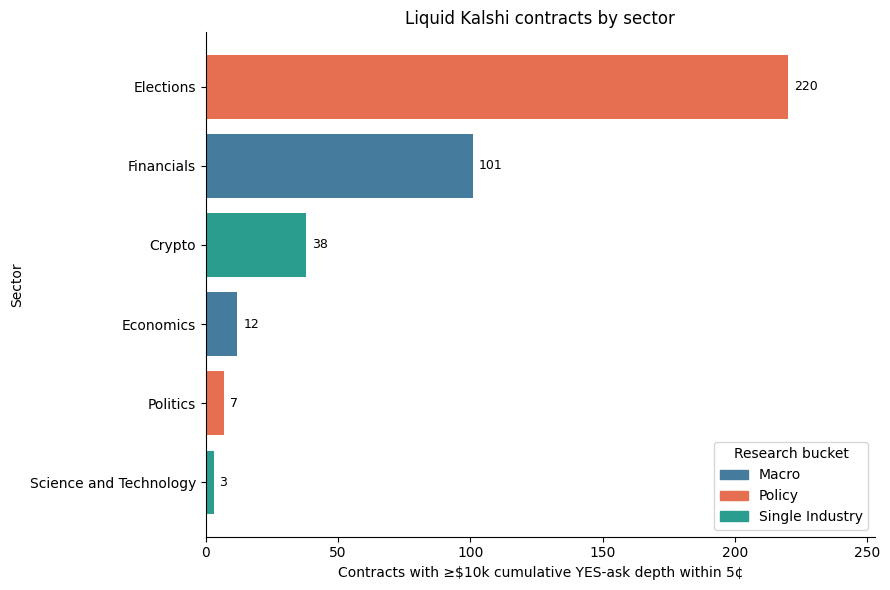

Saved sector visualization to /Users/nick/Desktop/Prediction Markets/figures/05_kalshi_liquid_contracts_by_sector.png


,event_category,research_bucket,contracts
3,Financials,macro,101
1,Economics,macro,12
2,Elections,policy,220
4,Politics,policy,7
0,Crypto,single-industry,38
5,Science and Technology,single-industry,3


In [17]:
import matplotlib.pyplot as plt

SECTOR_FIGURE_PATH = Path("figures/05_kalshi_liquid_contracts_by_sector.png")
SECTOR_FIGURE_PATH.parent.mkdir(exist_ok=True)

sector_counts = (
    liquid_contracts.groupby(["event_category", "research_bucket"])
    .size()
    .rename("contracts")
    .reset_index()
    .sort_values("contracts", ascending=True)
)
BUCKET_COLORS = {
    "macro": "#457B9D",
    "policy": "#E76F51",
    "single-industry": "#2A9D8F",
    "geopolitical": "#6D597A",
}

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    sector_counts["event_category"],
    sector_counts["contracts"],
    color=sector_counts["research_bucket"].map(BUCKET_COLORS),
)
for bar, count in zip(bars, sector_counts["contracts"]):
    ax.text(
        bar.get_width() + max(sector_counts["contracts"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=bucket.replace("-", " ").title())
    for bucket, color in BUCKET_COLORS.items()
    if bucket in set(sector_counts["research_bucket"])
]
ax.legend(handles=legend_handles, title="Research bucket", loc="lower right")
ax.set_title("Liquid Kalshi contracts by sector")
ax.set_xlabel("Contracts with ≥$10k cumulative YES-ask depth within 5¢")
ax.set_ylabel("Sector")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, max(sector_counts["contracts"]) * 1.15)
fig.tight_layout()
fig.savefig(SECTOR_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved sector visualization to {SECTOR_FIGURE_PATH.resolve()}")
sector_counts.sort_values(["research_bucket", "contracts"], ascending=[True, False])

## Liquidity-screen result

Run cells 9–10 to generate this snapshot. The retained universe requires both:

- a live reconstructed YES spread of ≤$0.05; and
- at least $10,000 of **cumulative** executable YES-ask depth across all qualifying book levels.

The output preserves the original listed quote, the live reconstructed quote, the number of eligible ask levels, eligible contracts, and cumulative eligible ask depth, so every retained market can be audited.

Output: `data/kalshi_active_contracts_liquid_10k_5c.csv`